In [1]:
from corr import add_snr_psf
import numpy as np 
import rasterio as rio 

def read_tiff(path):
    with rio.open(path) as src:
        return src.read(10)
    
img = read_tiff('/Data_large/marine/Datasets/VENuS/ds_L0/perfect/ASH_L0_12430_20191207_MultiLayer_mask_OK.tif')

# MTF Kernel

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def optical_mtf(f, f_number, wavelength):
    """
    Calculate the optical MTF for a given spatial frequency, F-number, and wavelength.
    
    Parameters:
    - f: Spatial frequency (cycles/mm)
    - f_number: F-number of the optical system
    - wavelength: Wavelength of light (mm)
    
    Returns:
    - MTF value for the given frequency.
    """
    f_c = 1 / (wavelength * f_number)  # Cutoff frequency
    # Apply the formula for optical MTF
    if np.abs(f) > f_c:
        return 0
    else:
        return (2 / np.pi) * (np.arccos(f / f_c) - (f / f_c) * np.sqrt(1 - (f / f_c) ** 2))

def detector_mtf(f, pixel_pitch):
    """
    Calculate the detector MTF using the sinc function.
    
    Parameters:
    - f: Spatial frequency (cycles/mm)
    - pixel_pitch: Pixel pitch (mm)
    
    Returns:
    - MTF value for the given frequency.
    """
    return np.sinc(f * pixel_pitch)

def total_mtf(fx, fy, f_number, wavelength, pixel_pitch):
    """
    Calculate the total MTF (Optical + Detector) for given spatial frequencies.
    
    Parameters:
    - fx, fy: Spatial frequencies (cycles/mm) in x and y directions
    - f_number: F-number of the optical system
    - wavelength: Wavelength of light (mm)
    - pixel_pitch: Pixel pitch (mm)
    
    Returns:
    - Total MTF value.
    """
    f = np.sqrt(fx**2 + fy**2)
    return optical_mtf(f, f_number, wavelength) * detector_mtf(f, pixel_pitch)

# Parameters
def get_venus_params():
    # https://www.eoportal.org/satellite-missions/venus#VENuS.html.6
    # https://en.wikipedia.org/wiki/VENμS
    
    # Pixel pitch and F-number for VENµS Super Spectral Camera (VSSC)
    f_number = 7.  # F-number for the VENµS VSSC
    pixel_pitch = 0.0169  # Pixel pitch in mm 5200 pixels in 88 mm
    MTF_at_nyquist = 0.2 # https://www.spiedigitallibrary.org/conference-proceedings-of-spie/11180/111804F/Measuring-modeling-and-removing-optical-straylight-from-venμs-super-spectral/10.1117/12.2536078.full
    params = {'f_number': f_number, 'pixel_pitch': pixel_pitch, 'MTF_at_nyquist': MTF_at_nyquist}
    return params

def get_sen2_params():
    aperture =  150 # mm 
    focal_length = 600 # mm
    MTF_at_nyquist = 0.3
    f_number = focal_length / aperture
    pixel_pitch = None
    params = {'f_number': f_number, 'pixel_pitch': pixel_pitch, 'MTF_at_nyquist': MTF_at_nyquist}
    return params


# n = 7  # Size of the MTF kernel
# wavelength = 0.0008  # Wavelength in mm (800 nm)
# f_number, pixel_pitch = get_venus_params()

# # Generate MTF kernel
# mtf_kernel = np.zeros((n, n))
# fx_range = np.linspace(-0.5, 0.5, n)  # Spatial frequency range
# fy_range = np.linspace(-0.5, 0.5, n)

# for i, fx in enumerate(fx_range):
#     for j, fy in enumerate(fy_range):
#         mtf_kernel[i, j] = total_mtf(fx, fy, f_number, wavelength, pixel_pitch)

# # Plot the MTF kernel
# mtf_kernel = mtf_kernel / mtf_kernel.sum()
# plt.imshow(mtf_kernel, extent=(-0.5, 0.5, -0.5, 0.5), cmap='viridis')
# plt.colorbar(label='MTF')
# plt.title('2D MTF Kernel')
# plt.xlabel('Spatial Frequency (cycles/mm) in X')
# plt.ylabel('Spatial Frequency (cycles/mm) in Y')
# plt.show()

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve


class OpticalSystem:
    def __init__(self, 
                 sensor, 
                 M_b_n_TGT, 
                 SNR,
                 wavelength=0.0008):
        
        # sensor: must be either 'sentinel' or 'venus'
        M_b_n_SRC = self.stored_params(sensor)['MTF_at_nyquist']
        self.wavelength = wavelength  # Wavelength in mm (800 nm)
        pixel_pitch = self.stored_params(sensor)['pixel_pitch']
        f_number = self.stored_params(sensor)['f_number']
        self.l_ref = 30.0  # Reference luminance for noise addition
        
        assert M_b_n_TGT <= M_b_n_SRC, 'Target MTF must be less than or equal to the source MTF'
        self.M_b_n_TGT = M_b_n_TGT # 
        assert SNR > 0, 'SNR must be greater than 0'
        assert M_b_n_SRC > 0, 'MTF at Nyquist frequency must be greater than 0'
        # Kernel Config:
        self.SNR = SNR
        kernel_size = 7  # Size of the kernel
        self.mtf_kernel = self.compute_mtf_kernel(pixel_pitch, f_number, M_b_n_SRC, M_b_n_TGT, wavelength, kernel_size)
        self.psf_kernel = self.compute_psf_kernel(self.mtf_kernel)
        

    def compute_mtf_kernel(self, pixel_pitch, f_number, M_b_n_SRC, M_b_n_TGT, wavelength, kernel_size):
        """
        Computes a 2D MTF kernel based on instrument parameters, including F-number.
        
        Args:
        - pixel_pitch (float): Pixel pitch (sampling frequency inverse).
        - f_number (float): F-number of the optical system.
        - M_b_n_SRC (float): MTF amplitude at the Nyquist frequency for the specific band (SRC original).
        - M_b_n_TGT (float): MTF amplitude at the Nyquist frequency for the specific band (Target MTF).
        - wavelength (float): Wavelength of the light (in meters) for which MTF is computed.
        - kernel_size (int): Size of the output MTF kernel (n x n). Should be odd.
        
        Returns:
        - mtf_kernel (numpy.ndarray): 2D MTF kernel of size (n x n).
        """
        # pixel_pitch, f_number, M_b_n_SRC, M_b_n_TGT, wavelength, kernel_size = self.pixel_pitch, self.f_number, self.M_b_n, self.M_b_n, self.wavelength, self.kernel_size
        
        # Compute sampling frequency (fs) and Nyquist frequency (fN)
        sampling_frequency = 1.0 / pixel_pitch  # Sampling frequency (fs)
        nyquist_frequency = sampling_frequency / 2  # Nyquist frequency (fN)
        
        # Compute cutoff frequency (fc) based on F-number and wavelength
        cutoff_frequency = 1 / (wavelength * f_number)  # Cutoff frequency (fc)
        normalized_cutoff_frequency = cutoff_frequency / nyquist_frequency  # Normalize with respect to Nyquist frequency
        
        # Create a frequency grid (u, v) in normalized coordinates (-1 to 1)
        u = np.linspace(-1, 1, kernel_size)
        v = np.linspace(-1, 1, kernel_size)
        U, V = np.meshgrid(u, v)
        
        # Compute the radial frequency k(u, v)
        K = np.sqrt(U**2 + V**2)  # Radial spatial frequency in normalized units
        
        # Apply the MTF formula to compute the MTF values on the grid
        MTF = np.exp(np.log(M_b_n_TGT / M_b_n_SRC) * K**2)  # Gaussian hypotheis (OrbitalAI paper)
        
        # Set MTF to zero beyond the normalized cutoff frequency
        MTF[K > normalized_cutoff_frequency] = 0
        
        # Normalize the MTF kernel
        mtf_kernel = MTF / np.max(MTF)
        
        return mtf_kernel


    @staticmethod
    def compute_psf_kernel(mtf_kernel):
        """
        Computes a 2D PSF kernel by taking the inverse Fourier transform of the MTF kernel.
        
        Args:
        - mtf_kernel (numpy.ndarray): 2D MTF kernel.
        
        Returns:
        - psf_kernel (numpy.ndarray): 2D PSF kernel.
        """
        # Compute the inverse 2D Fourier transform of the MTF kernel
        psf_kernel = np.fft.ifft2(mtf_kernel)
        
        # Shift the zero-frequency component to the center
        psf_kernel = np.fft.fftshift(psf_kernel)
        
        # Take the magnitude (real part) since the PSF is real-valued
        psf_kernel = np.abs(psf_kernel)
        
        # Normalize the PSF kernel to make its sum equal to 1
        psf_kernel /= np.sum(psf_kernel)
        
        return psf_kernel


    def stored_params(self, sensor):
        # Parameters
        # VENUS:
        # https://www.eoportal.org/satellite-missions/venus#VENuS.html.6
        # https://en.wikipedia.org/wiki/VENμS
        # Pixel pitch and F-number for VENµS Super Spectral Camera (VSSC)
        # f_number = 7.  # F-number for the VENµS VSSC
        # pixel_pitch = 0.0169  # Pixel pitch in mm 5200 pixels in 69 mm
        # MTF_at_nyquist = 0.2 # https://www.spiedigitallibrary.org/conference-proceedings-of-spie/11180/111804F/Measuring-modeling-and-removing-optical-straylight-from-venμs-super-spectral/10.1117/12.2536078.full
        VENUS = {'f_number': 7., 'pixel_pitch': 69/5200, 'MTF_at_nyquist': 0.2}
        ########################################################
        # Sentinel-2:
        aperture =  150 # mm 
        focal_length = 600 # mm
        # MTF_at_nyquist = 0.3 # From OrbitalAI paper.
        f_number = focal_length / aperture
        # pixel_pitch = 7.5 micro meters # Available in the paper: https://www.sciencedirect.com/topics/materials-science/sentinel-2
        SENTINEL = {'f_number': f_number, 'pixel_pitch': 0.0075, 'MTF_at_nyquist': 0.3}
        
        if sensor == 'sentinel':
            return SENTINEL
        elif sensor == 'venus':
            return VENUS

    
    def plot_kernels(self):
        # Plot the PSF and MTF kernels side by side
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        # Plot the PSF kernel
        axes[0].imshow(self.psf, cmap='viridis', interpolation='nearest')
        axes[0].set_title("2D PSF Kernel")
        axes[0].set_xlabel('X-axis')
        axes[0].set_ylabel('Y-axis')
        # BEGIN: Add colorbar
        cbar = fig.colorbar(axes[0].images[0], ax=axes[0], orientation='vertical')
        # Plot the MTF kernel
        axes[1].imshow(self.mtf_kernel, cmap='viridis', interpolation='nearest')
        axes[1].set_title("2D MTF Kernel")
        axes[1].set_xlabel('X-axis')
        axes[1].set_ylabel('Y-axis')
        # BEGIN: Add colorbar
        cbar = fig.colorbar(axes[1].images[0], ax=axes[1], orientation='vertical')
        # END: Add colorbar

        plt.tight_layout()
        plt.show()


    def apply(self, img, normalize=False):
        """
        Adds noise to the image based on the provided SNR and applies a PSF kernel convolution.
        
        Parameters:
        img (ndarray): Input image.
        snr (float): Signal-to-noise ratio for noise addition. If 0 or less, no noise is added.
        psf_percentage (float): Percentage to control the range of the PSF kernel values.
        normalize (bool): Whether to normalize the output to match the original image's mean and std.
        ks (int): Kernel size for PSF convolution.
        l_ref (float): Scaling factor for noise addition.
        
        Returns:
        ndarray: The image after noise addition and PSF convolution.
        """
        l_ref = self.l_ref
        # Step 2: Generate random noise with zero mean and unit variance
        random_noise = np.random.normal(loc=0, scale=1, size=img.shape)

        # Step 3: Add noise to the image based on SNR
        if self.SNR > 0:
            noise = l_ref * random_noise / self.SNR
            noisy_data = img + noise  # Scale noise by l_ref and snr
        else:
            noisy_data = img  # No noise added if SNR <= 0

        # Step 4: Convolve the noisy data with the normalized PSF kernel
        psf_convolved_data = convolve(noisy_data, self.psf_kernel, mode='mirror')
        
        # Step 5: Normalize output to match original data distribution if requested
        if normalize:
            mean_orig, std_orig = img.mean(), img.std()
            mean_conv, std_conv = psf_convolved_data.mean(), psf_convolved_data.std()
            # Avoid division by zero in normalization
            if std_conv != 0:
                adjusted_convolved_data = (psf_convolved_data - mean_conv) * (std_orig / std_conv) + mean_orig
            else:
                adjusted_convolved_data = psf_convolved_data  # If std_conv is 0, keep as is
            return adjusted_convolved_data
        
        else:
            return psf_convolved_data


venus_optics = OpticalSystem('venus', 0.2, SNR=5)
sen2_optics = OpticalSystem('sentinel', 0.3, SNR=5)

# NOISE

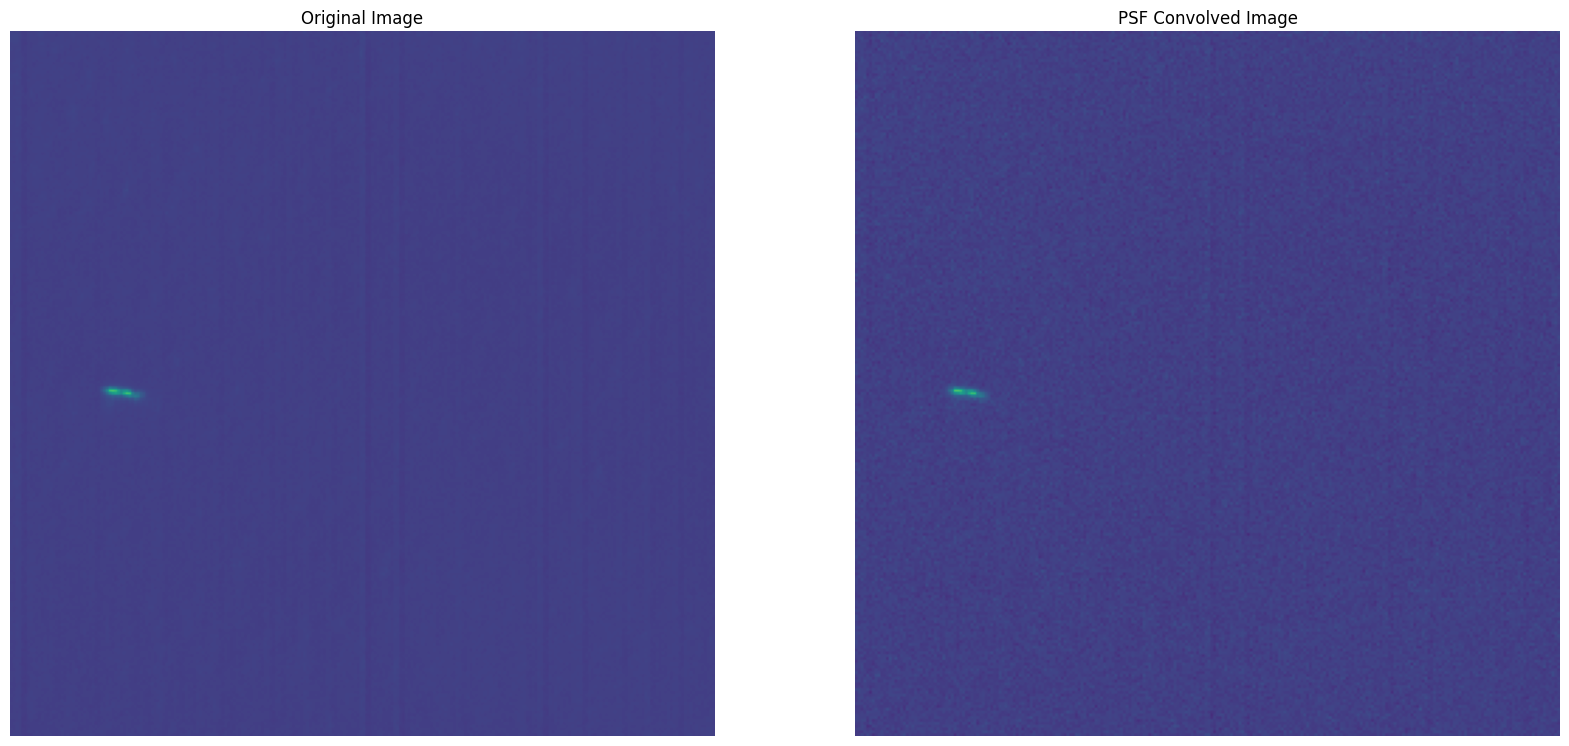

In [60]:
import matplotlib.pyplot as plt

venus_optics = OpticalSystem('venus', 0.2, SNR=10)


VMIN = 0
VMAX = 200

fig, axes = plt.subplots(1, 2, figsize=(20, 15))
# Plot the original image
axes[0].imshow(img[1500:1750, 500:750], vmin=VMIN, vmax=VMAX)
axes[0].axis('off')
axes[0].set_title('Original Image')
# Plot the PSF convolved image
axes[1].imshow(venus_optics.apply(img)[1500:1750, 500:750], 
               vmin=VMIN, vmax=VMAX)
axes[1].axis('off')
axes[1].set_title('PSF Convolved Image')
plt.show()